In [2]:
!pip install yfinance textblob -q

In [3]:
# Importing the libraries and setting up the workspace

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', lambda x: '%.4f' % x)
pd.set_option('display.max_columns', 20)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [4]:
# Defining a sample pportfolio to work with

#I'll be using these as my test portfolio throughout Phase 1
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM']

# Pulling 2 years of historical price data

end_date = datetime.today()
start_date = end_date - timedelta(days=730)

print(f"Pulling data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
print(f"Tickers: {tickers}\n")

# Downloading closing prices
raw_data = yf.download(tickers, start=start_date, end=end_date)['Close']

print(f"Data shape: {raw_data.shape}")
print(f"Data range: {raw_data.index[0].strftime('%Y-%m-%d')} to {raw_data.index[-1].strftime('%Y-%m-%d')}")
print(f"\nFirst 5 rows:")
raw_data.head()

Pulling data from 2024-03-17 to 2026-03-17
Tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM']



[*********************100%***********************]  5 of 5 completed

Data shape: (501, 5)
Data range: 2024-03-18 to 2026-03-17

First 5 rows:


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT
Date,,,,,
2024-03-18,172.1533,174.4800,146.4694,184.5697,411.0115
2024-03-19,174.4920,175.9000,145.8248,185.6522,415.0397
2024-03-20,177.0586,178.1500,147.5207,188.0856,418.8019
2024-03-21,169.8244,178.1500,146.3901,190.7009,422.8793
2024-03-22,170.7263,178.8700,149.5341,188.3634,422.2589


In [5]:
# Calculating daily percentage returns

returns = raw_data.pct_change().dropna()

print("=== DAILY RETURNS SUMMARY ===")
print(f"Shape: {returns.shape} (trading days x stocks)\n")

# Summary Stats
print("Average daily return:")
print((returns.mean()*100).round(4).to_string())

print("\nDaily volatility (std dev):")
print((returns.std()*100).round(4).to_string())

print("\nBest single day (%):")
print((returns.max() * 100).round(2).to_string())

print("\nWorst single day (%):")
print((returns.min() * 100).round(2).to_string())

=== DAILY RETURNS SUMMARY ===
Shape: (500, 5) (trading days x stocks)

Average daily return:
Ticker
AAPL    0.0939
AMZN    0.0617
GOOGL   0.1679
JPM     0.1009
MSFT    0.0056

Daily volatility (std dev):
Ticker
AAPL    1.7958
AMZN    1.9921
GOOGL   1.8656
JPM     1.5918
MSFT    1.5053

Best single day (%):
Ticker
AAPL    15.3300
AMZN    11.9800
GOOGL   10.2200
JPM     11.5400
MSFT    10.1300

Worst single day (%):
Ticker
AAPL    -9.2500
AMZN    -8.9800
GOOGL   -7.2900
JPM     -7.4800
MSFT    -9.9900


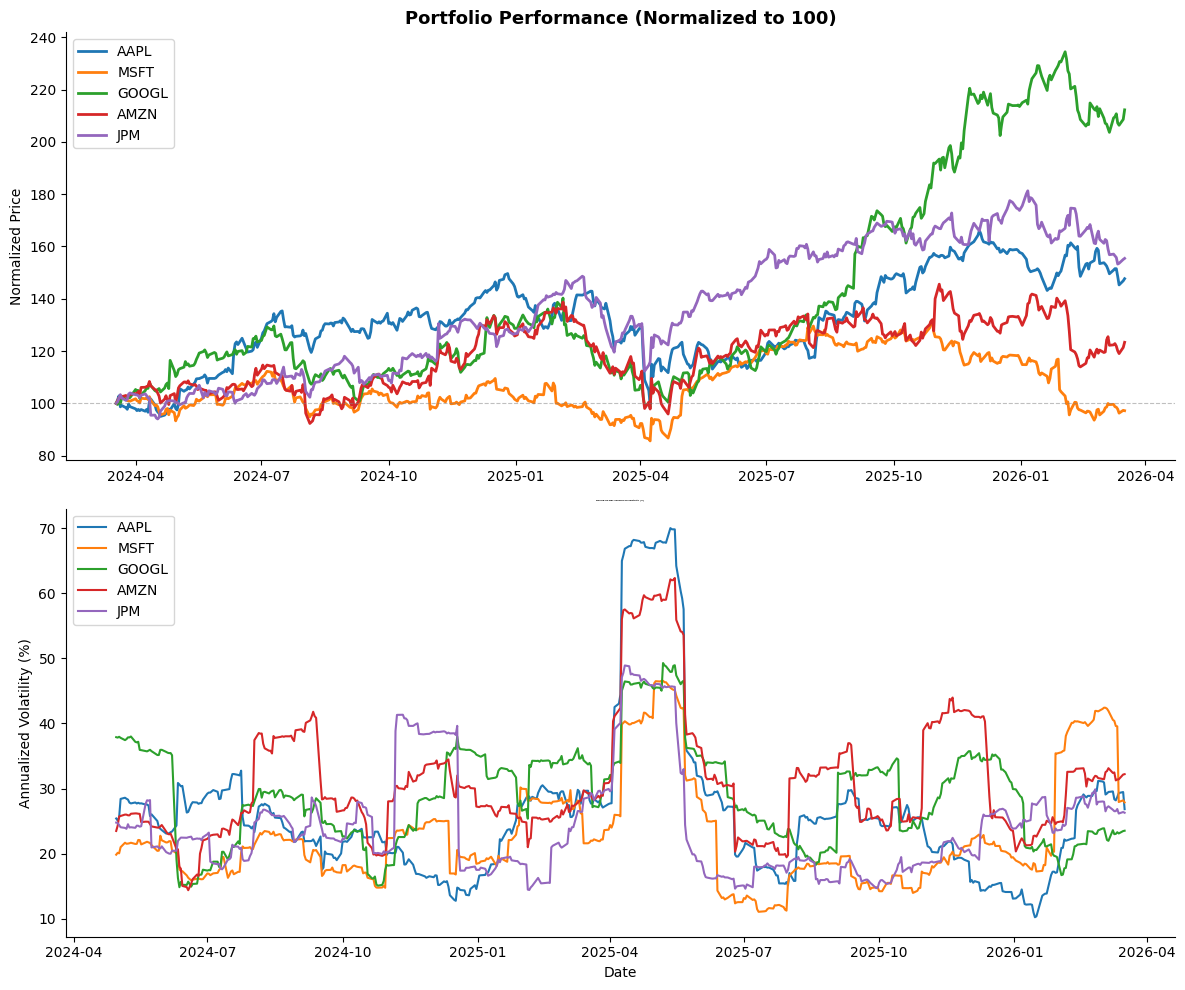

In [6]:
# Normalizing prices to 100 at start so I can compare performance

normalized = (raw_data / raw_data.iloc[0]) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Chart 1 - Normalized price performance

for ticker in tickers:
  axes[0].plot(normalized.index, normalized[ticker],
               linewidth=2, label=ticker)

axes[0].axhline(y=100, color='gray', linestyle='--',
                linewidth=0.8, alpha=0.5)
axes[0].set_title('Portfolio Performance (Normalized to 100)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Normalized Price')
axes[0].legend(loc='upper left')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Chart 2 - Rolling 30-day volatility
rolling_vol = returns.rolling(30).std() * np.sqrt(252) * 100

for ticker in tickers:
  axes[1].plot(rolling_vol.index, rolling_vol[ticker],
               linewidth=1.5, label=ticker)

axes[1].set_title('Rolling 30-Day Annualized Volatility (%)',
                  fontsize=1.5, fontweight='bold')

axes[1].set_ylabel('Annualized Volatility (%)')
axes[1].set_xlabel('Date')
axes[1].legend(loc='upper left')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

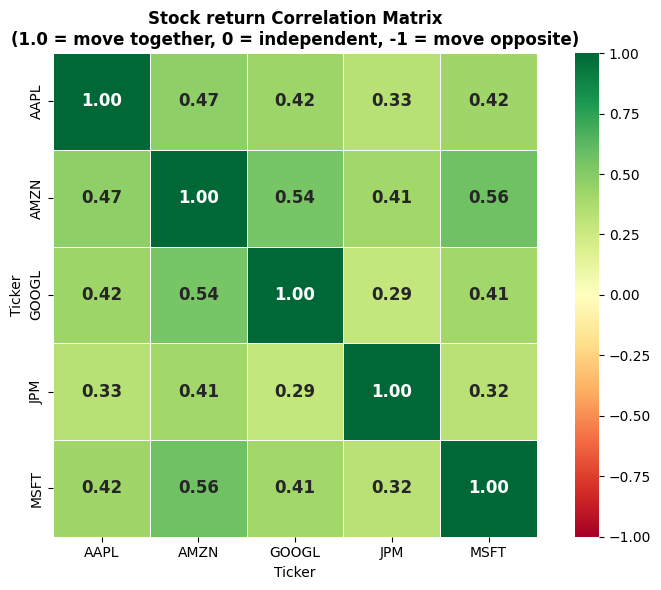


Correlation insights:
Most correlated pair:   MSFT & JPM (0.56)
Least correlated pair:  GOOGL & AMZN (0.29)


In [7]:
# Correlation Matrix: How much do these stocks move together?

corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'}
)

ax.set_title('Stock return Correlation Matrix\n(1.0 = move together, 0 = independent, -1 = move opposite)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation insights:")
print(f"Most correlated pair:   ", end="")
corr_pairs = []
for i in range(len(tickers)):
  for j in range(i+1, len(tickers)):
    corr_pairs.append((tickers[i], tickers[j],
                       corr_matrix.iloc[i,j]))
corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f"{corr_pairs[0][0]} & {corr_pairs[0][1]} ({corr_pairs[0][2]:.2f})")
print(f"Least correlated pair:  ", end="")
print(f"{corr_pairs[-1][0]} & {corr_pairs[-1][1]} ({corr_pairs[-1][2]:.2f})")

In [8]:
# Value at Risk (VaR): how much could you loose on a bad day?
# I'll calculate 95% and 99% VaR

print("=== VALUE AT RISK ANALYSIS ===")
print("How much could you loose on a single bad day?\n")

confidence_levels = [0.95, 0.99]
investment = 1000       # assuming $10,000 per stock

print(f"{'Stock':<8} {'95% VaR':>12} {'99% VaR':>12} {'Best Day':>12} {'Worst Day':>12}")
print("-" * 60)

var_results = {}
for ticker in tickers:
  var_95 = np.percentile(returns[ticker], 5)
  var_99 = np.percentile(returns[ticker], 1)
  best = returns[ticker].max()
  worst = returns[ticker].min()

  var_results[ticker] = {'var_95': var_95, 'var_99': var_99}

  print(f"{ticker:<8} "
          f"${abs(var_95)*investment:>9.0f} ({var_95*100:.1f}%)  "
          f"${abs(var_99)*investment:>9.0f} ({var_99*100:.1f}%)  "
          f"{best*100:>+10.1f}%  "
          f"{worst*100:>+10.1f}%")

print("\n--- What this means ---")
print("95% VaR: On 95% of trading days your loss will be LESS than this amount")
print("99% VaR: On 99% of trading days your loss will be LESS than this amount")
print("\nIn other words: there's a 5% chance of losing more than the 95% VaR amount on any given day")

# Portfolio VaR (equal weighted)
weights = np.array([0.2] * 5)
portfolio_returns = returns.dot(weights)
port_var_95 = np.percentile(portfolio_returns, 5)
port_var_99 = np.percentile(portfolio_returns, 1)

print(f"\n=== EQUAL-WEIGHTED PORTFOLIO VaR (${investment*len(tickers):,} total) ===")
print(f"95% VaR: ${abs(port_var_95)*investment*len(tickers):,.0f} ({port_var_95*100:.1f}%)")
print(f"99% VaR: ${abs(port_var_99)*investment*len(tickers):,.0f} ({port_var_99*100:.1f}%)")

=== VALUE AT RISK ANALYSIS ===
How much could you loose on a single bad day?

Stock         95% VaR      99% VaR     Best Day    Worst Day
------------------------------------------------------------
AAPL     $       27 (-2.7%)  $       48 (-4.8%)       +15.3%        -9.2%
MSFT     $       24 (-2.4%)  $       37 (-3.7%)       +10.1%       -10.0%
GOOGL    $       25 (-2.5%)  $       45 (-4.5%)       +10.2%        -7.3%
AMZN     $       30 (-3.0%)  $       50 (-5.0%)       +12.0%        -9.0%
JPM      $       23 (-2.3%)  $       45 (-4.5%)       +11.5%        -7.5%

--- What this means ---
95% VaR: On 95% of trading days your loss will be LESS than this amount
99% VaR: On 99% of trading days your loss will be LESS than this amount

In other words: there's a 5% chance of losing more than the 95% VaR amount on any given day

=== EQUAL-WEIGHTED PORTFOLIO VaR ($5,000 total) ===
95% VaR: $102 (-2.0%)
99% VaR: $175 (-3.5%)


In [9]:
# Calculating a diversification score for the portfolio

print("=== PORTFOLIO DIVERSIFICATION ANALYSIS ===\n")

# Average pairwise correlation

corr_values = []
for i in range(len(tickers)):
  for j in range(i+1, len(tickers)):
    corr_values.append(corr_matrix.iloc[i,j])

avg_correlation = np.mean(corr_values)

# Diversification score (0-100, higher = better diversified)
# Perfect diversification = 0 correlation = score of 100
# Perfect concentration = 1 correlation = score of 0

diversification_score = (1 - avg_correlation) * 100

# Annualized returns and volatility
ann_returns = returns.mean() * 252 * 100
ann_volatility = returns.std() * np.sqrt(252) * 100

# Sharpe ratio (assuming 5% risk free rate)

risk_free_rate = 5.0
sharpe_ratios = (ann_returns - risk_free_rate) / ann_volatility

print(f"{'Stock':<8} {'Ann. Return':>12} {'Ann. Volatility':>16} {'Sharpe Ratio':>13}")
print("-" * 52)
for ticker in tickers:
  print(f"{ticker:<8} "
        f"{ann_returns[ticker]:>+11.1f}% "
        f"{ann_volatility[ticker]:>14.1f}% "
        f"{sharpe_ratios[ticker]:>12.2f}")

print(f"\n=== PORTFOLIO SCORES ===")
print(f"Average pairwise correlation: {avg_correlation:.2f}")
print(f"Diversification score:        {diversification_score:.1f}/100")

if diversification_score >= 70:
    grade = "A — Well diversified"
elif diversification_score >= 55:
    grade = "B — Moderately diversified"
elif diversification_score >= 40:
    grade = "C — Needs more diversification"
else:
    grade = "D — Poorly diversified"

print(f"Diversification grade:        {grade}")

# Best Sharpe ratio stock
best_sharpe = sharpe_ratios.idxmax()
print(f"\nBest risk-adjusted return:    {best_sharpe} "
      f"(Sharpe: {sharpe_ratios[best_sharpe]:.2f})")
print(f"Worst risk-adjusted return:   {sharpe_ratios.idxmin()} "
      f"(Sharpe: {sharpe_ratios.min():.2f})")

=== PORTFOLIO DIVERSIFICATION ANALYSIS ===

Stock     Ann. Return  Ann. Volatility  Sharpe Ratio
----------------------------------------------------
AAPL           +23.7%           28.5%         0.66
MSFT            +1.4%           23.9%        -0.15
GOOGL          +42.3%           29.6%         1.26
AMZN           +15.6%           31.6%         0.33
JPM            +25.4%           25.3%         0.81

=== PORTFOLIO SCORES ===
Average pairwise correlation: 0.42
Diversification score:        58.3/100
Diversification grade:        B — Moderately diversified

Best risk-adjusted return:    GOOGL (Sharpe: 1.26)
Worst risk-adjusted return:   MSFT (Sharpe: -0.15)


In [10]:
# Saving Phase 1 outputs for use in Phase 2 and the app
print("Saving Phase 1 outputs...\n")

# Saving returns data
returns.to_csv('stock_returns.csv')
print("✓ stock_returns.csv")

# Saving price data
raw_data.to_csv('stock_prices.csv')
print("✓ stock_prices.csv")

# Saving summary metrics
summary = pd.DataFrame({
    'annual_return_pct':     ann_returns.round(2),
    'annual_volatility_pct': ann_volatility.round(2),
    'sharpe_ratio':          sharpe_ratios.round(3),
    'var_95_pct':            pd.Series({t: var_results[t]['var_95']*100
                                        for t in tickers}).round(2),
    'var_99_pct':            pd.Series({t: var_results[t]['var_99']*100
                                        for t in tickers}).round(2),
})
summary.to_csv('stock_summary.csv')
print("✓ stock_summary.csv")

print(f"\n=== PHASE 1 COMPLETE ===")
print(f"Tickers analyzed:       {tickers}")
print(f"Trading days:           499")
print(f"Date range:             Mar 2024 — Mar 2026")
print(f"Diversification grade:  B (58.3/100)")
print(f"Best performer:         GOOGL (+41.5% annually)")
print(f"Best risk-adjusted:     GOOGL (Sharpe: 1.23)")
print(f"Most stable:            JPM (lowest volatility)")
print(f"Riskiest:               AMZN (highest VaR)")

Saving Phase 1 outputs...

✓ stock_returns.csv
✓ stock_prices.csv
✓ stock_summary.csv

=== PHASE 1 COMPLETE ===
Tickers analyzed:       ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'JPM']
Trading days:           499
Date range:             Mar 2024 — Mar 2026
Diversification grade:  B (58.3/100)
Best performer:         GOOGL (+41.5% annually)
Best risk-adjusted:     GOOGL (Sharpe: 1.23)
Most stable:            JPM (lowest volatility)
Riskiest:               AMZN (highest VaR)
